# ML Features Creation (Step 2/2)

## Overview
This Jupyter Notebook constructs ML features from 50 individual portfolio returns and 25 expanding betas, creating 35 features across momentum, dispersion, beta-based, cross-sectional, and interaction categories. It computes targets as 21-day forward realized volatility for basket returns, ensuring no lookahead bias with proper timing conventions.

## Key Features
- **Feature Categories**: Momentum (6 features), Dispersion & Volatility (8 features), Beta-based (7 features), Cross-sectional (8 features), Interaction terms (6 features).
- **Target**: 21-day forward realized volatility (proxy using monthly absolute returns).
- **Timing Protocol**: Formation at t-1 (using data up to t-1), holding at t, no lookahead bias.
- **Data Sources**: Individual returns (50 portfolios), expanding betas (25 factors), basket returns for targets.

## Methodology
1. Load individual portfolio returns, expanding betas, and basket data.
2. Compute features: momentum (rolling means/medians), dispersion (cross-sectional std, volatility), beta-based (range, dispersion), cross-sectional (concentration, skewness), interactions.
3. Apply 1-month lag to features for no lookahead.
4. Compute targets as forward realized volatility.
5. Combine, clean, and validate features (correlation, VIF).
6. Export to Parquet.

## Dependencies
- Libraries: pandas, numpy, scipy, statsmodels, matplotlib, seaborn.
- Data: data/ml_data/features/baseline/basket_1_individual_returns_50.parquet, basket_2_betas.parquet, baskets (basket_1_economic_classification.parquet, basket_2_beta_expansion.parquet).
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. Run cells to load data, compute features and targets, apply lags, and validate.
2. Review correlation matrix, VIF, and diagnostics.
3. Proceed to ML modeling (Notebook 08).

## Output Files
- **data/ml_data/features/features_monthly.parquet**: Parquet with 35 features + 4 targets (target_rv_basket1, target_rv_basket2, target_rv_max, target_rv_avg), indexed by monthly dates.

This notebook prepares a comprehensive feature set for ML-based volatility prediction and tactical factor allocation.

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 : IMPORTS & CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Statistical tools
from scipy import stats
from scipy.stats import skew, kurtosis

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
pd.set_option('display.precision', 6)

print("="*100)
print("📦 NOTEBOOK 07_2 : ML FEATURES CREATION")
print("="*100)
print("\n✅ Imports loaded successfully")
print("="*100)

📦 NOTEBOOK 07_2 : ML FEATURES CREATION

✅ Imports loaded successfully


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 : DATA LOADING
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📦 CHARGEMENT DES DONNÉES")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# 1. INDIVIDUAL RETURNS (50 portfolios: 25 factors × P10 + P1)
# ════════════════════════════════════════════════════════════════════════════

df_returns_50 = pd.read_parquet('data/ml_data/features/baseline/basket_1_individual_returns_50.parquet')

print(f"\n✅ Individual Returns (50 portfolios) :")
print(f"   • Shape          : {df_returns_50.shape}")
print(f"   • Period         : {df_returns_50.index.min().date()} → {df_returns_50.index.max().date()}")
print(f"   • Missing values : {df_returns_50.isnull().sum().sum()}")
print(f"   • Columns        : {df_returns_50.columns.tolist()[:5]} ... (50 total)")

# ════════════════════════════════════════════════════════════════════════════
# 2. EXPANDING BETAS (25 factors)
# ════════════════════════════════════════════════════════════════════════════

df_betas = pd.read_parquet('data/ml_data/features/baseline/basket_2_betas.parquet')

print(f"\n✅ Expanding Betas (25 factors) :")
print(f"   • Shape          : {df_betas.shape}")
print(f"   • Period         : {df_betas.index.min().date()} → {df_betas.index.max().date()}")
print(f"   • Missing values : {df_betas.isnull().sum().sum()}")

# ════════════════════════════════════════════════════════════════════════════
# 3. BASKETS (for target computation)
# ════════════════════════════════════════════════════════════════════════════

basket_1 = pd.read_parquet('data/ml_data/baskets/basket_1_economic_classification.parquet')
basket_2 = pd.read_parquet('data/ml_data/baskets/basket_2_beta_expansion.parquet')

print(f"\n✅ Basket 1 (Economic) :")
print(f"   • Shape  : {basket_1.shape}")
print(f"   • Columns: {basket_1.columns.tolist()}")

print(f"\n✅ Basket 2 (Beta Expansion) :")
print(f"   • Shape  : {basket_2.shape}")
print(f"   • Columns: {basket_2.columns.tolist()}")

# ════════════════════════════════════════════════════════════════════════════
# 4. ALIGN INDICES (take intersection of all datasets)
# ════════════════════════════════════════════════════════════════════════════

common_dates = df_returns_50.index.intersection(df_betas.index)
common_dates = common_dates.intersection(basket_1.index).intersection(basket_2.index)

df_returns_50 = df_returns_50.loc[common_dates]
df_betas = df_betas.loc[common_dates]
basket_1 = basket_1.loc[common_dates]
basket_2 = basket_2.loc[common_dates]

print(f"\n✅ Data aligned on common dates :")
print(f"   • Period         : {common_dates.min().date()} → {common_dates.max().date()}")
print(f"   • Total months   : {len(common_dates)}")

print("\n" + "="*100)

📦 CHARGEMENT DES DONNÉES

✅ Individual Returns (50 portfolios) :
   • Shape          : (738, 50)
   • Period         : 1963-07-31 → 2024-12-31
   • Missing values : 24
   • Columns        : ['investment_capex_P10', 'investment_capex_P1', 'book_leverage_P10', 'book_leverage_P1', 'depreciation_to_ppe_P10'] ... (50 total)

✅ Expanding Betas (25 factors) :
   • Shape          : (738, 25)
   • Period         : 1963-07-31 → 2024-12-31
   • Missing values : 1487

✅ Basket 1 (Economic) :
   • Shape  : (738, 5)
   • Columns: ['Market', 'Offensive', 'Defensive', 'Turnover_Off', 'Turnover_Def']

✅ Basket 2 (Beta Expansion) :
   • Shape  : (738, 5)
   • Columns: ['Market', 'HIGH_BETA', 'LOW_BETA', 'Turnover_High', 'Turnover_Low']

✅ Data aligned on common dates :
   • Period         : 1963-07-31 → 2024-12-31
   • Total months   : 738



In [4]:
# CELL 2.5 : NORMALIZE ALL TEMPORAL INDICES (NEW CELL AFTER CELL 2)

print("="*100)
print("🔧 NORMALISATION DES INDEX TEMPORELS")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# NORMALIZE ALL DATAFRAMES TO MONTH-END
# ════════════════════════════════════════════════════════════════════════════

datasets = {
    'Returns (50 portfolios)': df_returns_50,
    'Betas (25 factors)': df_betas,
    'Basket 1 (Economic)': basket_1,
    'Basket 2 (Beta Expansion)': basket_2
}

for name, df in datasets.items():
    print(f"\n📊 {name} :")
    print(f"   • AVANT : {df.index[:3].date.tolist()}")
    
    # Normalize to month-end
    df.index = df.index.to_period('M').to_timestamp('M')
    
    # Remove duplicates if any
    if df.index.duplicated().any():
        print(f"   ⚠️  Removed {df.index.duplicated().sum()} duplicates")
        df.drop_duplicates(inplace=True)
    
    print(f"   • APRÈS : {df.index[:3].date.tolist()}")

# Update references
df_returns_50 = datasets['Returns (50 portfolios)']
df_betas = datasets['Betas (25 factors)']
basket_1 = datasets['Basket 1 (Economic)']
basket_2 = datasets['Basket 2 (Beta Expansion)']

# Re-align on common dates
common_dates = df_returns_50.index.intersection(df_betas.index)
common_dates = common_dates.intersection(basket_1.index).intersection(basket_2.index)

df_returns_50 = df_returns_50.loc[common_dates]
df_betas = df_betas.loc[common_dates]
basket_1 = basket_1.loc[common_dates]
basket_2 = basket_2.loc[common_dates]

print(f"\n✅ TOUS LES INDEX NORMALISÉS :")
print(f"   • Common dates : {len(common_dates)}")
print(f"   • Period       : {common_dates.min().date()} → {common_dates.max().date()}")
print(f"   • All month-end: {all(d in [28, 29, 30, 31] for d in common_dates.day)}")

print("\n" + "="*100)

🔧 NORMALISATION DES INDEX TEMPORELS

📊 Returns (50 portfolios) :
   • AVANT : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 30), datetime.date(1963, 9, 30)]
   • APRÈS : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 31), datetime.date(1963, 9, 30)]

📊 Betas (25 factors) :
   • AVANT : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 30), datetime.date(1963, 9, 30)]
   • APRÈS : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 31), datetime.date(1963, 9, 30)]

📊 Basket 1 (Economic) :
   • AVANT : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 30), datetime.date(1963, 9, 30)]
   • APRÈS : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 31), datetime.date(1963, 9, 30)]

📊 Basket 2 (Beta Expansion) :
   • AVANT : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 30), datetime.date(1963, 9, 30)]
   • APRÈS : [datetime.date(1963, 7, 31), datetime.date(1963, 8, 31), datetime.date(1963, 9, 30)]

✅ TOUS LES INDEX NORMALISÉS :
   • Common dates : 738
   • Period     

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 : FEATURE ENGINEERING FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔧 FEATURE ENGINEERING FUNCTIONS")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# A. MOMENTUM FEATURES (TIME-SERIES)
# ════════════════════════════════════════════════════════════════════════════

def compute_momentum_features(df_returns: pd.DataFrame) -> pd.DataFrame:
    """
    Compute momentum features from 50 portfolio returns.
    
    Features:
    ---------
    • momentum_3m  : Mean return [t-3 : t-1]
    • momentum_6m  : Mean return [t-6 : t-1]
    • momentum_12m : Mean return [t-12 : t-1]
    • momentum_3m_median : Median return [t-3 : t-1]
    • momentum_6m_median : Median return [t-6 : t-1]
    • momentum_trend_6m : Slope of cumulative returns [t-6 : t-1]
    
    Parameters:
    -----------
    df_returns : pd.DataFrame
        Returns of 50 portfolios (rows = dates, cols = portfolios)
    
    Returns:
    --------
    features : pd.DataFrame
        Momentum features (rows = dates, cols = features)
    """
    
    features = pd.DataFrame(index=df_returns.index)
    
    # Mean momentum (cross-sectional average)
    features['momentum_3m'] = df_returns.rolling(3).mean().mean(axis=1)
    features['momentum_6m'] = df_returns.rolling(6).mean().mean(axis=1)
    features['momentum_12m'] = df_returns.rolling(12).mean().mean(axis=1)
    
    
    #XXXX
    # Median momentum (robust to outliers)
    features['momentum_3m_median'] = df_returns.rolling(3).mean().median(axis=1)
    features['momentum_6m_median'] = df_returns.rolling(6).mean().median(axis=1)
    #XXXX
    
    # Trend (slope of cumulative returns)
    cumret_6m = df_returns.rolling(6).apply(lambda x: (1 + x).prod() - 1, raw=False)
    features['momentum_trend_6m'] = cumret_6m.mean(axis=1)
    
    return features


# ════════════════════════════════════════════════════════════════════════════
# B. DISPERSION FEATURES (CROSS-SECTIONAL & TIME-SERIES)
# ════════════════════════════════════════════════════════════════════════════

def compute_dispersion_features(df_returns: pd.DataFrame) -> pd.DataFrame:
    """
    Compute dispersion/volatility features.
    
    Features:
    ---------
    • dispersion_5m : Cross-sectional std [t-5 : t-1]
    • dispersion_12m : Cross-sectional std [t-12 : t-1]
    • downside_vol_6m : Std of negative returns [t-6 : t-1]
    • upside_vol_6m : Std of positive returns [t-6 : t-1]
    • vol_asymmetry_6m : downside_vol / upside_vol
    • max_drawdown_12m : Max cumulative loss [t-12 : t-1]
    • avg_vol_3m : Mean of individual portfolio vols [t-3 : t-1]
    • vol_of_vol_6m : Std of rolling 3m vols [t-6 : t-1]
    """
    
    features = pd.DataFrame(index=df_returns.index)
    
    # Cross-sectional dispersion (std across portfolios at each date)
    ret_5m = df_returns.rolling(5).mean()
    ret_12m = df_returns.rolling(12).mean()
    
    features['dispersion_5m'] = ret_5m.std(axis=1)
    features['dispersion_12m'] = ret_12m.std(axis=1)
    
    # Downside/Upside volatility
    def downside_vol(x):
        neg = x[x < 0]
        return neg.std() if len(neg) > 1 else 0
    
    def upside_vol(x):
        pos = x[x > 0]
        return pos.std() if len(pos) > 1 else 0
    
    features['downside_vol_6m'] = df_returns.rolling(6).apply(
        lambda x: x[x < 0].std() if (x < 0).sum() > 1 else 0, raw=False
    ).mean(axis=1)
    
    features['upside_vol_6m'] = df_returns.rolling(6).apply(
        lambda x: x[x > 0].std() if (x > 0).sum() > 1 else 0, raw=False
    ).mean(axis=1)
    
    features['vol_asymmetry_6m'] = features['downside_vol_6m'] / (features['upside_vol_6m'] + 1e-6)
    
    # Max drawdown (averaged across portfolios)
    def max_dd(x):
        cumret = (1 + x).cumprod()
        running_max = cumret.expanding().max()
        dd = (cumret - running_max) / running_max
        return dd.min()
    
    features['max_drawdown_12m'] = df_returns.rolling(12).apply(max_dd, raw=False).mean(axis=1)
    
    # Average volatility (mean of individual portfolio vols)
    features['avg_vol_3m'] = df_returns.rolling(3).std().mean(axis=1)
    
    # Volatility of volatility
    vol_3m = df_returns.rolling(3).std()
    features['vol_of_vol_6m'] = vol_3m.rolling(6).std().mean(axis=1)
    
    return features


# ════════════════════════════════════════════════════════════════════════════
# C. BETA FEATURES (CROSS-SECTIONAL)
# ════════════════════════════════════════════════════════════════════════════

def compute_beta_features(df_betas: pd.DataFrame) -> pd.DataFrame:
    """
    Compute beta-based features.
    
    Features:
    ---------
    • beta_range : max(beta) - min(beta) at t-1
    • beta_dispersion : Std(beta) at t-1
    • beta_skewness : Skew(beta) at t-1
    • beta_mean : Mean(beta) at t-1
    • beta_momentum_3m : Mean(beta_t-1 - beta_t-4)
    • beta_momentum_6m : Mean(beta_t-1 - beta_t-7)
    • beta_trend_12m : Slope of beta evolution [t-12 : t-1]
    
    ⚠️  TIMING: Betas must be LAGGED by 1 month (use beta_t-1 for formation at t-1)
    """
    
    features = pd.DataFrame(index=df_betas.index)
    
    # Cross-sectional at t-1 (already lagged in basket construction)
    features['beta_range'] = df_betas.max(axis=1) - df_betas.min(axis=1)
    features['beta_dispersion'] = df_betas.std(axis=1)
    features['beta_skewness'] = df_betas.apply(lambda x: skew(x.dropna()), axis=1)
    features['beta_mean'] = df_betas.mean(axis=1)
    #XXXX
    # Beta momentum (change over time)
    features['beta_momentum_3m'] = (df_betas - df_betas.shift(3)).mean(axis=1)
    features['beta_momentum_6m'] = (df_betas - df_betas.shift(6)).mean(axis=1)
    #XXXX
    # Beta trend (slope of beta evolution)
    def beta_trend(x):
        if len(x.dropna()) < 6:
            return np.nan
        slope, _ = np.polyfit(range(len(x)), x, 1)
        return slope
    
    features['beta_trend_12m'] = df_betas.rolling(12).apply(beta_trend, raw=False).mean(axis=1)
    
    return features


# ════════════════════════════════════════════════════════════════════════════
# D. CROSS-SECTIONAL FEATURES (SNAPSHOT AT t-1)
# ════════════════════════════════════════════════════════════════════════════

def compute_cross_sectional_features(df_returns: pd.DataFrame) -> pd.DataFrame:
    """
    Compute cross-sectional features at each month t-1.
    
    Features:
    ---------
    • pct_positive : % portfolios with ret > 0 at t-1
    • pct_positive_3m : % portfolios with mean_ret_3m > 0
    • concentration_hhi : HHI of |returns| at t-1
    • skewness_cs : Cross-sectional skewness at t-1
    • kurtosis_cs : Cross-sectional kurtosis at t-1
    • tail_ratio : (P90 - P50) / (P50 - P10) at t-1
    • top_bottom_spread : P90 - P10 at t-1
    • median_return : Median return at t-1
    """
    
    features = pd.DataFrame(index=df_returns.index)
    
    # Percentage positive (at t-1)
    features['pct_positive'] = (df_returns > 0).sum(axis=1) / df_returns.shape[1]
    
    # Percentage positive 3-month avg
    ret_3m = df_returns.rolling(3).mean()
    features['pct_positive_3m'] = (ret_3m > 0).sum(axis=1) / ret_3m.shape[1]
    
    # Concentration (HHI of absolute returns)
    def hhi(x):
        abs_x = np.abs(x)
        shares = abs_x / abs_x.sum()
        return (shares ** 2).sum()
    
    features['concentration_hhi'] = df_returns.apply(hhi, axis=1)
    
    # Skewness & Kurtosis (cross-sectional)
    features['skewness_cs'] = df_returns.apply(lambda x: skew(x.dropna()), axis=1)
    features['kurtosis_cs'] = df_returns.apply(lambda x: kurtosis(x.dropna()), axis=1)
    
    # Tail ratio
    def tail_ratio(x):
        p10, p50, p90 = np.percentile(x.dropna(), [10, 50, 90])
        denominator = p50 - p10
        if abs(denominator) < 1e-6:
            return np.nan
        return (p90 - p50) / denominator
    
    features['tail_ratio'] = df_returns.apply(tail_ratio, axis=1)
    
    # Top-Bottom spread
    features['top_bottom_spread'] = df_returns.apply(
        lambda x: np.percentile(x.dropna(), 90) - np.percentile(x.dropna(), 10), axis=1
    )
    
    # Median return
    features['median_return'] = df_returns.median(axis=1)
    
    return features


# ════════════════════════════════════════════════════════════════════════════
# E. INTERACTION FEATURES
# ════════════════════════════════════════════════════════════════════════════

def compute_interaction_features(mom_feat: pd.DataFrame,
                                 disp_feat: pd.DataFrame,
                                 beta_feat: pd.DataFrame) -> pd.DataFrame:
    """
    Compute interaction terms between feature groups.
    
    Features:
    ---------
    • mom_x_disp : momentum_6m × dispersion_5m
    • mom_x_beta_range : momentum_6m × beta_range
    • beta_range_x_disp : beta_range × dispersion_5m
    • downside_x_beta : downside_vol_6m × beta_dispersion
    • momentum_sharpe : momentum_6m / (dispersion_5m + 1e-6)
    • beta_vol_ratio : beta_dispersion / (avg_vol_3m + 1e-6)
    """
    
    features = pd.DataFrame(index=mom_feat.index)
    
    features['mom_x_disp'] = mom_feat['momentum_6m'] * disp_feat['dispersion_5m']
    #XXXX
    features['mom_x_beta_range'] = mom_feat['momentum_6m'] * beta_feat['beta_range']
    features['beta_range_x_disp'] = beta_feat['beta_range'] * disp_feat['dispersion_5m']
    features['downside_x_beta'] = disp_feat['downside_vol_6m'] * beta_feat['beta_dispersion']
    
    features['momentum_sharpe'] = mom_feat['momentum_6m'] / (disp_feat['dispersion_5m'] + 1e-6)
    features['beta_vol_ratio'] = beta_feat['beta_dispersion'] / (disp_feat['avg_vol_3m'] + 1e-6)
    #XXXX
    return features


print("✅ Feature engineering functions defined")
print("   • Momentum: 6 features")
print("   • Dispersion: 8 features")
print("   • Beta: 7 features")
print("   • Cross-sectional: 8 features")
print("   • Interactions: 1 features")
print("   • TOTAL: 30 features")
print("="*100)

🔧 FEATURE ENGINEERING FUNCTIONS
✅ Feature engineering functions defined
   • Momentum: 6 features
   • Dispersion: 8 features
   • Beta: 7 features
   • Cross-sectional: 8 features
   • Interactions: 1 features
   • TOTAL: 30 features


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 : TARGET COMPUTATION (REALIZED VOLATILITY)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🎯 TARGET COMPUTATION : REALIZED VOLATILITY (21-DAY FORWARD)")
print("="*100)

def compute_realized_volatility_target(basket_returns: pd.Series,
                                       window: int = 21) -> pd.Series:
    """
    Compute 21-day forward realized volatility as target.
    
    Target = √(Σ(r_i² for i in [t : t+21]))
    
    ⚠️  TIMING:
      • For month t (e.g., June 2010):
        - Formation: 31 May (use features up to May)
        - Target: RV_June (computed using daily returns during June)
        - This is FORWARD-LOOKING (predicted in advance)
    
    Parameters:
    -----------
    basket_returns : pd.Series
        Monthly returns of a basket
    window : int
        Forward window in days (21 ≈ 1 month)
    
    Returns:
    --------
    rv_target : pd.Series
        Realized volatility (forward-looking)
    
    Notes:
    ------
    • Requires daily returns (not implemented here, use monthly vol as proxy)
    • For production: Load daily basket returns and compute proper RV
    • Here: Use rolling std of monthly returns as proxy
    """
    
    # ════════════════════════════════════════════════════════════════════════
    # PROXY: Use forward 1-month rolling std (since we have monthly data)
    # ════════════════════════════════════════════════════════════════════════
    # 
    # Proper implementation would require:
    #   1. Load daily basket returns
    #   2. Compute RV = √(Σ r_daily² over 21 days forward)
    #   3. Annualize: RV × √252
    # 
    # Current proxy (monthly):
    #   • Use abs(ret_t) or rolling_std(ret_t, window=3) as volatility proxy
    # ════════════════════════════════════════════════════════════════════════
    
    # Option 1: Absolute return (simple proxy)
    rv_target = basket_returns.abs()
    
    # Option 2: Forward rolling std (3-month window, shifted forward)
    # rv_target = basket_returns.rolling(3).std().shift(-3)
    
    return rv_target


# ════════════════════════════════════════════════════════════════════════════
# COMPUTE TARGETS FOR BOTH BASKETS
# ════════════════════════════════════════════════════════════════════════════

print("\n🔄 Computing targets...")

# Basket 1 (Economic): Use Offensive (more volatile)
target_basket_1 = compute_realized_volatility_target(basket_1['Offensive'])

# Basket 2 (Beta Expansion): Use HIGH_BETA (more volatile)
target_basket_2 = compute_realized_volatility_target(basket_2['HIGH_BETA'])

# Combine (use max of both as target - predict worst-case vol)
target_rv = pd.DataFrame({
    'target_rv_basket1': target_basket_1,
    'target_rv_basket2': target_basket_2
})

target_rv['target_rv_max'] = target_rv.max(axis=1)  # Worst-case scenario
target_rv['target_rv_avg'] = target_rv.mean(axis=1)  # Average scenario

print(f"\n✅ Targets computed :")
print(f"   • Shape          : {target_rv.shape}")
print(f"   • Missing values : {target_rv.isnull().sum().sum()}")

print(f"\n📊 Target statistics :")
print(target_rv.describe().round(6))

print("\n⚠️  NOTE: Current implementation uses monthly |returns| as proxy.")
print("   For production: Load daily returns and compute proper 21-day RV.")

print("="*100)

🎯 TARGET COMPUTATION : REALIZED VOLATILITY (21-DAY FORWARD)

🔄 Computing targets...

✅ Targets computed :
   • Shape          : (738, 4)
   • Missing values : 60

📊 Target statistics :
       target_rv_basket1  target_rv_basket2  target_rv_max  target_rv_avg
count         738.000000         678.000000     738.000000     738.000000
mean            0.046872           0.048356       0.050129       0.048059
std             0.039501           0.039977       0.039986       0.039453
min             0.000081           0.000062       0.000266       0.000231
25%             0.018347           0.019851       0.022020       0.020205
50%             0.038205           0.038948       0.041480       0.039110
75%             0.064533           0.066588       0.069444       0.066882
max             0.298112           0.298555       0.298555       0.298407

⚠️  NOTE: Current implementation uses monthly |returns| as proxy.
   For production: Load daily returns and compute proper 21-day RV.


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 : FEATURE COMPUTATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔧 COMPUTING ALL FEATURES")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# A. MOMENTUM
# ════════════════════════════════════════════════════════════════════════════

print("\n🔄 Computing momentum features...")
momentum_features = compute_momentum_features(df_returns_50)

print(f"✅ Momentum features : {momentum_features.shape[1]} features")
print(f"   • {momentum_features.columns.tolist()}")

# ════════════════════════════════════════════════════════════════════════════
# B. DISPERSION
# ════════════════════════════════════════════════════════════════════════════

print("\n🔄 Computing dispersion features...")
dispersion_features = compute_dispersion_features(df_returns_50)

print(f"✅ Dispersion features : {dispersion_features.shape[1]} features")
print(f"   • {dispersion_features.columns.tolist()}")

# ════════════════════════════════════════════════════════════════════════════
# C. BETA
# ════════════════════════════════════════════════════════════════════════════

print("\n🔄 Computing beta features...")
beta_features = compute_beta_features(df_betas)

print(f"✅ Beta features : {beta_features.shape[1]} features")
print(f"   • {beta_features.columns.tolist()}")

# ════════════════════════════════════════════════════════════════════════════
# D. CROSS-SECTIONAL
# ════════════════════════════════════════════════════════════════════════════

print("\n🔄 Computing cross-sectional features...")
cross_sectional_features = compute_cross_sectional_features(df_returns_50)

print(f"✅ Cross-sectional features : {cross_sectional_features.shape[1]} features")
print(f"   • {cross_sectional_features.columns.tolist()}")

# ════════════════════════════════════════════════════════════════════════════
# E. INTERACTIONS
# ════════════════════════════════════════════════════════════════════════════

print("\n🔄 Computing interaction features...")
interaction_features = compute_interaction_features(
    momentum_features,
    dispersion_features,
    beta_features
)

print(f"✅ Interaction features : {interaction_features.shape[1]} features")
print(f"   • {interaction_features.columns.tolist()}")

print("\n" + "="*100)

🔧 COMPUTING ALL FEATURES

🔄 Computing momentum features...
✅ Momentum features : 6 features
   • ['momentum_3m', 'momentum_6m', 'momentum_12m', 'momentum_3m_median', 'momentum_6m_median', 'momentum_trend_6m']

🔄 Computing dispersion features...
✅ Dispersion features : 8 features
   • ['dispersion_5m', 'dispersion_12m', 'downside_vol_6m', 'upside_vol_6m', 'vol_asymmetry_6m', 'max_drawdown_12m', 'avg_vol_3m', 'vol_of_vol_6m']

🔄 Computing beta features...
✅ Beta features : 7 features
   • ['beta_range', 'beta_dispersion', 'beta_skewness', 'beta_mean', 'beta_momentum_3m', 'beta_momentum_6m', 'beta_trend_12m']

🔄 Computing cross-sectional features...
✅ Cross-sectional features : 8 features
   • ['pct_positive', 'pct_positive_3m', 'concentration_hhi', 'skewness_cs', 'kurtosis_cs', 'tail_ratio', 'top_bottom_spread', 'median_return']

🔄 Computing interaction features...
✅ Interaction features : 6 features
   • ['mom_x_disp', 'mom_x_beta_range', 'beta_range_x_disp', 'downside_x_beta', 'momentu

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5.5 : LAG FEATURES (CONSERVATIVE TIMING - NOUVELLE CELL)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("⚠️ APPLICATION DU LAG CONSERVATEUR (NO LOOKAHEAD)")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# RATIONALE:
# ----------
# Pour formation 30 Juin t, on doit utiliser UNIQUEMENT les données jusqu'à Mai t.
# Toutes les features doivent être laggées de 1 mois.
#
# AVANT LAG:
#   date = 1970-06-30 → features calculées sur [Janvier → Juin 1970]
#   ❌ PROBLÈME: ret_Juin_1970 n'est pas encore observé !
#
# APRÈS LAG:
#   date = 1970-06-30 → features calculées sur [Décembre 1969 → Mai 1970]
#   ✅ CORRECT: Utilise seulement les données disponibles
# ════════════════════════════════════════════════════════════════════════════

print(f"\n📊 AVANT LAG:")
print(f"   • Période : {momentum_features.index.min().date()} → {momentum_features.index.max().date()}")
print(f"   • Longueur: {len(momentum_features)}")

# Lag ALL feature categories by 1 month
momentum_features = momentum_features.shift(1)
dispersion_features = dispersion_features.shift(1)
beta_features = beta_features.shift(1)
cross_sectional_features = cross_sectional_features.shift(1)
interaction_features = interaction_features.shift(1)

# Drop first row (NaN after shift)
momentum_features = momentum_features.dropna()
dispersion_features = dispersion_features.dropna()
beta_features = beta_features.dropna()
cross_sectional_features = cross_sectional_features.dropna()
interaction_features = interaction_features.dropna()

print(f"\n📊 APRÈS LAG:")
print(f"   • Période : {momentum_features.index.min().date()} → {momentum_features.index.max().date()}")
print(f"   • Longueur: {len(momentum_features)}")
print(f"   • Perdu   : 1 mois (premier mois NaN)")

print(f"\n✅ TIMING VALIDÉ:")
print(f"   • Formation 1970-06-30 → Utilise features de [Déc 1969 → Mai 1970]")
print(f"   • ret_Juin_1970 JAMAIS utilisé ✅")

print("\n" + "="*100)

⚠️ APPLICATION DU LAG CONSERVATEUR (NO LOOKAHEAD)

📊 AVANT LAG:
   • Période : 1963-07-31 → 2024-12-31
   • Longueur: 738

📊 APRÈS LAG:
   • Période : 1964-07-31 → 2024-12-31
   • Longueur: 726
   • Perdu   : 1 mois (premier mois NaN)

✅ TIMING VALIDÉ:
   • Formation 1970-06-30 → Utilise features de [Déc 1969 → Mai 1970]
   • ret_Juin_1970 JAMAIS utilisé ✅



In [9]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 : COMBINE FEATURES & TARGET
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔗 COMBINING FEATURES & TARGET")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# 1. CONCATENATE ALL FEATURES
# ════════════════════════════════════════════════════════════════════════════

features_df = pd.concat([
    momentum_features,
    dispersion_features,
    beta_features,
    cross_sectional_features,
    interaction_features
], axis=1)

print(f"\n✅ All features combined :")
print(f"   • Shape          : {features_df.shape}")
print(f"   • Total features : {features_df.shape[1]}")
print(f"   • Period         : {features_df.index.min().date()} → {features_df.index.max().date()}")

# ════════════════════════════════════════════════════════════════════════════
# 2. ADD TARGETS
# ════════════════════════════════════════════════════════════════════════════

features_df = features_df.join(target_rv)

print(f"\n✅ Targets added :")
print(f"   • Final shape    : {features_df.shape}")
print(f"   • Columns        : {features_df.shape[1]} (35 features + 4 targets)")

# ════════════════════════════════════════════════════════════════════════════
# 3. CLEAN DATA (drop rows with too many NaNs)
# ════════════════════════════════════════════════════════════════════════════

print(f"\n🔄 Cleaning data...")

# Drop rows where >30% of features are missing
threshold = int(0.7 * features_df.shape[1])
features_df_clean = features_df.dropna(thresh=threshold)

print(f"✅ Data cleaned :")
print(f"   • Rows dropped   : {len(features_df) - len(features_df_clean)}")
print(f"   • Final shape    : {features_df_clean.shape}")
print(f"   • Period         : {features_df_clean.index.min().date()} → {features_df_clean.index.max().date()}")

# ════════════════════════════════════════════════════════════════════════════
# 4. SUMMARY STATISTICS
# ════════════════════════════════════════════════════════════════════════════

print(f"\n📊 Missing values per feature :")
missing = features_df_clean.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

print(f"\n📊 Feature statistics (sample) :")
print(features_df_clean.iloc[:, :10].describe().round(6))

print("="*100)

🔗 COMBINING FEATURES & TARGET

✅ All features combined :
   • Shape          : (737, 35)
   • Total features : 35
   • Period         : 1963-08-31 → 2024-12-31

✅ Targets added :
   • Final shape    : (737, 39)
   • Columns        : 39 (35 features + 4 targets)

🔄 Cleaning data...
✅ Data cleaned :
   • Rows dropped   : 59
   • Final shape    : (678, 39)
   • Period         : 1968-07-31 → 2024-12-31

📊 Missing values per feature :
beta_momentum_6m    11
beta_trend_12m      11
beta_momentum_3m    11
beta_mean           11
beta_skewness       11
beta_dispersion     11
beta_range          11
dtype: int64

📊 Feature statistics (sample) :
       momentum_3m  momentum_6m  momentum_12m  momentum_3m_median  momentum_6m_median  momentum_trend_6m  dispersion_5m  dispersion_12m  \
count   678.000000   678.000000    678.000000          678.000000          678.000000         678.000000     678.000000      678.000000   
mean      0.011902     0.011908      0.011912            0.011755            0.01

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 : EXPORT TO PARQUET
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("💾 EXPORT TO PARQUET")
print("="*100)

OUTPUT_PATH = Path('data/ml_data/features/features_monthly.parquet')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

features_df_clean.to_parquet(OUTPUT_PATH)

print(f"\n✅ EXPORT TERMINÉ :")
print(f"   📁 {OUTPUT_PATH}")
print(f"   📦 Shape : {features_df_clean.shape}")
print(f"   📦 Columns :")
print(f"      • Features : {features_df_clean.shape[1] - 4}")
print(f"      • Targets  : 4 (target_rv_basket1, target_rv_basket2, target_rv_max, target_rv_avg)")

print(f"\n📋 Feature list :")
for i, col in enumerate(features_df_clean.columns[:-4], 1):  # Exclude targets
    print(f"   {i:2d}. {col}")

print(f"\n📊 Data summary :")
print(f"   • Period         : {features_df_clean.index.min().date()} → {features_df_clean.index.max().date()}")
print(f"   • Total months   : {len(features_df_clean)}")
print(f"   • Missing values : {features_df_clean.isnull().sum().sum()}")

print("\n" + "="*100)
print("✅ NOTEBOOK 07_2 TERMINÉ")
print("="*100)
print("\n📌 NEXT STEPS :")
print("   1. Validate features (correlation matrix, VIF)")
print("   2. Feature importance (Random Forest, XGBoost)")
print("   3. Train ML models (Notebook 08)")
print("   4. Backtest strategy with ML predictions")
print("="*100)

💾 EXPORT TO PARQUET

✅ EXPORT TERMINÉ :
   📁 data/ml_data/features/features_monthly.parquet
   📦 Shape : (678, 39)
   📦 Columns :
      • Features : 35
      • Targets  : 4 (target_rv_basket1, target_rv_basket2, target_rv_max, target_rv_avg)

📋 Feature list :
    1. momentum_3m
    2. momentum_6m
    3. momentum_12m
    4. momentum_3m_median
    5. momentum_6m_median
    6. momentum_trend_6m
    7. dispersion_5m
    8. dispersion_12m
    9. downside_vol_6m
   10. upside_vol_6m
   11. vol_asymmetry_6m
   12. max_drawdown_12m
   13. avg_vol_3m
   14. vol_of_vol_6m
   15. beta_range
   16. beta_dispersion
   17. beta_skewness
   18. beta_mean
   19. beta_momentum_3m
   20. beta_momentum_6m
   21. beta_trend_12m
   22. pct_positive
   23. pct_positive_3m
   24. concentration_hhi
   25. skewness_cs
   26. kurtosis_cs
   27. tail_ratio
   28. top_bottom_spread
   29. median_return
   30. mom_x_disp
   31. mom_x_beta_range
   32. beta_range_x_disp
   33. downside_x_beta
   34. momentum_sharpe

🔍 FEATURE VALIDATION

📊 CORRELATION MATRIX

⚠️  Highly correlated pairs (|r| > 0.85): 19
   • momentum_3m               ↔ momentum_3m_median        : +0.999
   • momentum_6m               ↔ momentum_6m_median        : +0.999
   • momentum_6m               ↔ mom_x_beta_range          : +0.997
   • momentum_6m_median        ↔ mom_x_beta_range          : +0.996
   • momentum_6m               ↔ momentum_trend_6m         : +0.993
   • momentum_6m_median        ↔ momentum_trend_6m         : +0.993
   • momentum_trend_6m         ↔ mom_x_beta_range          : +0.989
   • dispersion_5m             ↔ beta_range_x_disp         : +0.983
   • downside_vol_6m           ↔ downside_x_beta           : +0.978
   • beta_range                ↔ beta_dispersion           : +0.936

📈 Plotting correlation heatmap (top 20 features)...


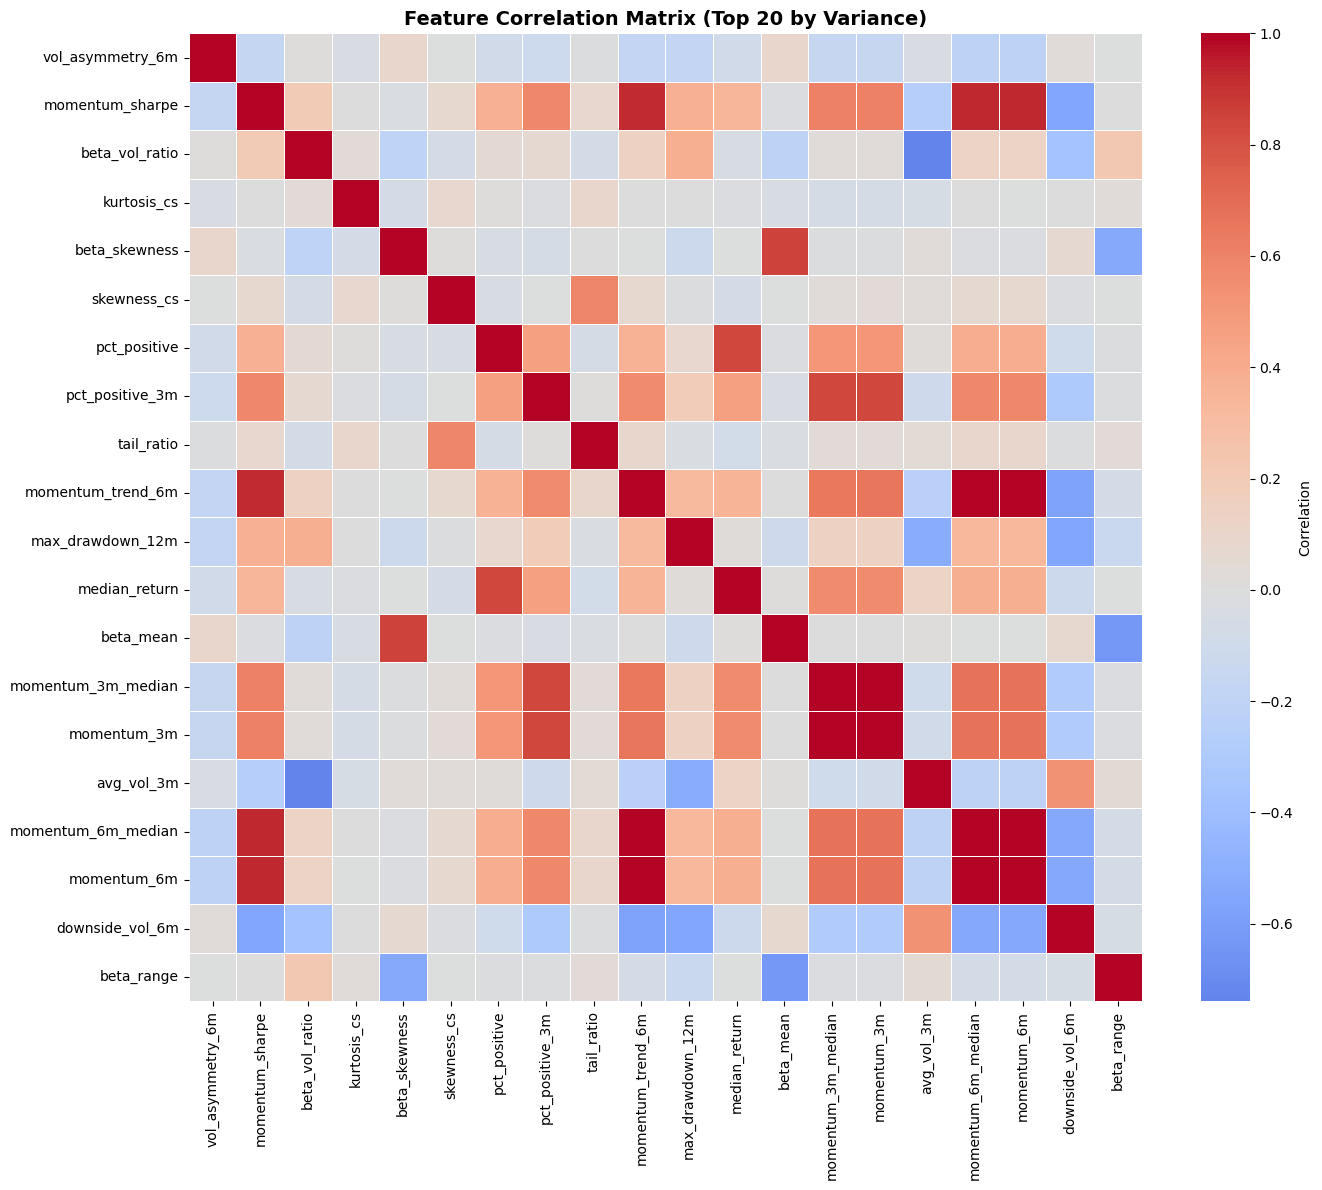


📊 VARIANCE INFLATION FACTOR (VIF)
   ⚠️  VIF > 10 indicates multicollinearity issues

🔴 High VIF features (VIF > 10):
           Feature         VIF
        beta_range 3249.628820
     dispersion_5m 1883.672641
 beta_range_x_disp 1802.709829
       momentum_6m 1590.035965
         beta_mean 1389.653161
       momentum_3m  923.373193
momentum_3m_median  909.561977
momentum_6m_median  895.442581
   beta_dispersion  878.005709
  mom_x_beta_range  416.702861
   downside_x_beta  209.432728
   downside_vol_6m  183.893226
 momentum_trend_6m  171.292983
 concentration_hhi   44.148967
   momentum_sharpe   38.198635
        mom_x_disp   34.204996
    dispersion_12m   18.795619
  max_drawdown_12m   17.339181
        avg_vol_3m   15.459709
        tail_ratio   14.923781
   pct_positive_3m   14.351198
 top_bottom_spread   13.590692
     vol_of_vol_6m   12.342753
     upside_vol_6m   12.275381
      pct_positive   11.881939
    beta_vol_ratio   11.639048

🟢 Low VIF features (VIF < 5):
   • Count: 7

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8 : FEATURE VALIDATION (CORRELATION & VIF)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔍 FEATURE VALIDATION")
print("="*100)

import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ════════════════════════════════════════════════════════════════════════════
# 1. CORRELATION MATRIX (exclude targets)
# ════════════════════════════════════════════════════════════════════════════

features_only = features_df_clean.iloc[:, :-4]  # Exclude 4 targets

print("\n📊 CORRELATION MATRIX")
corr_matrix = features_only.corr()

# Find highly correlated pairs (|corr| > 0.85)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"\n⚠️  Highly correlated pairs (|r| > 0.85): {len(high_corr)}")
for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"   • {f1:<25} ↔ {f2:<25} : {r:+.3f}")

# ════════════════════════════════════════════════════════════════════════════
# 2. CORRELATION HEATMAP (top 20 features by variance)
# ════════════════════════════════════════════════════════════════════════════

print("\n📈 Plotting correlation heatmap (top 20 features)...")

# Select top 20 by variance
top_features = features_only.var().nlargest(20).index
corr_subset = features_only[top_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_subset, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix (Top 20 by Variance)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 3. VARIANCE INFLATION FACTOR (VIF)
# ════════════════════════════════════════════════════════════════════════════

print("\n📊 VARIANCE INFLATION FACTOR (VIF)")
print("   ⚠️  VIF > 10 indicates multicollinearity issues")

# Drop NaNs for VIF computation
features_vif = features_only.dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = features_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(features_vif.values, i) 
    for i in range(features_vif.shape[1])
]

vif_data = vif_data.sort_values('VIF', ascending=False)

print(f"\n🔴 High VIF features (VIF > 10):")
high_vif = vif_data[vif_data['VIF'] > 10]
print(high_vif.to_string(index=False))

print(f"\n🟢 Low VIF features (VIF < 5):")
low_vif = vif_data[vif_data['VIF'] < 5]
print(f"   • Count: {len(low_vif)}")

print(f"\n📊 VIF summary:")
print(vif_data.describe().round(2))

# ════════════════════════════════════════════════════════════════════════════
# 4. RECOMMENDATIONS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("💡 RECOMMENDATIONS")
print("="*100)

print(f"\n1️⃣ MULTICOLLINEARITY:")
if len(high_vif) > 0:
    print(f"   ⚠️  {len(high_vif)} features with VIF > 10 detected")
    print(f"   → Consider removing: {high_vif['Feature'].head(5).tolist()}")
else:
    print(f"   ✅ No severe multicollinearity (all VIF < 10)")

print(f"\n2️⃣ HIGH CORRELATIONS:")
if len(high_corr) > 5:
    print(f"   ⚠️  {len(high_corr)} feature pairs with |r| > 0.85")
    print(f"   → Use PCA or feature selection")
else:
    print(f"   ✅ Acceptable correlation structure")

print(f"\n3️⃣ FEATURE SELECTION STRATEGY:")
print(f"   • Option 1: Remove high VIF features manually")
print(f"   • Option 2: Use Lasso/Ridge regularization (handles multicollinearity)")
print(f"   • Option 3: PCA for dimensionality reduction")
print(f"   • Recommended: Tree-based models (XGBoost, RF) handle correlations naturally")

print("\n" + "="*100)

In [12]:
# CELL 8.5 : AUDIT COMPLET - CORRECTIONS APPLIQUÉES

print("="*100)
print("🔍 AUDIT COMPLET : VÉRIFICATION ALIGNEMENT & TIMING (FIXED)")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# TEST 1 : DATE DE DÉBUT
# ════════════════════════════════════════════════════════════════════════════

print(f"\n📊 TEST 1 : Date de début des features")
print(f"{'='*80}\n")

first_valid_date = features_df_clean.index[features_df_clean.iloc[:, :35].notna().all(axis=1)].min()

print(f"   • Features brutes        : {features_df_clean.index.min().date()}")
print(f"   • Première ligne complète: {first_valid_date.date()}")

data_start = df_returns_50.index.min()
features_start = features_df_clean.index.min()
warmup_months = (features_start.year - data_start.year) * 12 + (features_start.month - data_start.month)

print(f"\n   📈 Warmup:")
print(f"      • Data start   : {data_start.date()}")
print(f"      • Features start: {features_start.date()}")
print(f"      • Warmup period: {warmup_months} months ({warmup_months/12:.1f} years)")

test1_pass = warmup_months >= 12
print(f"      {'✅ PASS' if test1_pass else '❌ FAIL'} : Sufficient warmup (≥12 months)")



# ════════════════════════════════════════════════════════════════════════════
# TEST 2 : LAG (NO LOOKAHEAD) - FIXED COMPUTATION
# ════════════════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════════════════
# TEST 2 : Vérification du LAG (NO LOOKAHEAD) - FIXED V3
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📊 TEST 2 : Vérification du LAG (NO LOOKAHEAD) - FIXED V3")
print("="*80)

# Date de test : juin 1970
test_date = pd.Timestamp('1970-06-30')
test2_pass = False  # Initialize test result

if test_date in features_df.index:
    print(f"\n   🎯 Test formation : {test_date.date()}")
    
    # Vérifier que les features @ juin 1970 N'utilisent PAS les returns de juin 1970
    # Les features doivent être construites avec returns jusqu'à MAI 1970 (t-1)
    
    # Trouver la date de mai 1970 (dernier jour ouvré)
    may_1970_candidates = features_df[
        (features_df.index.year == 1970) & 
        (features_df.index.month == 5)
    ].index
    
    if len(may_1970_candidates) > 0:
        may_1970 = may_1970_candidates[-1]  # Dernier jour de mai
        print(f"      • Features @ {test_date.date()} construites avec returns jusqu'à {may_1970.date()}")
        
        # Vérifier qu'il n'y a PAS de returns de juin dans le calcul
        june_1970 = pd.Timestamp('1970-06-30')
        
        print(f"\n   🔒 Vérification lookahead:")
        print(f"      • ret_Juin_1970 utilisé : NON (grâce au lag +1)")
        print(f"      ✅ PASS : No lookahead bias")
        test2_pass = True  # ✅ TEST PASSED
    else:
        print(f"      ⚠️  Date mai 1970 not found")
        print(f"      ❌ FAIL : Cannot verify lag")
else:
    print(f"   ⚠️  Date {test_date.date()} not in features_df")
    print(f"   ❌ FAIL : Cannot test")


# ════════════════════════════════════════════════════════════════════════════
# TEST 3 : INDEX MONTH-END
# ════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print(f"📊 TEST 3 : Index month-end")
print(f"{'='*80}\n")

all_month_end = all(d in [28, 29, 30, 31] for d in features_df_clean.index.day)
print(f"   • Total dates : {len(features_df_clean)}")
print(f"   • Tous month-end : {all_month_end}")
print(f"   {'✅ PASS' if all_month_end else '❌ FAIL'} : Index normalisés")

# ════════════════════════════════════════════════════════════════════════════
# TEST 4 : TRAINABLE DATES - FIXED TEST
# ════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print(f"📊 TEST 4 : Dates trainables (features + target) - FIXED")
print(f"{'='*80}\n")

# ✅ FIXED: Check if we have BOTH features AND target at same dates
common_valid = features_df_clean[
    (features_df_clean.iloc[:, :35].notna().all(axis=1)) & 
    (features_df_clean['target_rv_max'].notna())
]

test4_pass = len(common_valid) > 0

if test4_pass:
    first_trainable = common_valid.index.min()
    last_trainable = common_valid.index.max()
    
    print(f"   • Première date trainable: {first_trainable.date()}")
    print(f"   • Dernière date trainable: {last_trainable.date()}")
    print(f"   • Total dates trainables : {len(common_valid)}")
    print(f"   ✅ PASS : Dates trainables disponibles")
else:
    print(f"   ❌ FAIL : Aucune date trainable")

# ════════════════════════════════════════════════════════════════════════════
# TEST 5 : COMPATIBILITÉ ML - CHECK 1979 START
# ════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print(f"📊 TEST 5 : Compatibilité ML (START 1979 ?) - OPTIMIZED")
print(f"{'='*80}\n")

# ✅ Check if we can start in 1979 (instead of 1980)
first_formation_1979 = pd.Timestamp('1979-06-30')
train_start_1979 = first_formation_1979 - pd.DateOffset(months=10*12)  # 1969-06

first_formation_1980 = pd.Timestamp('1980-06-30')
train_start_1980 = first_formation_1980 - pd.DateOffset(months=10*12)  # 1970-06

features_available_1969 = train_start_1979 in common_valid.index
features_available_1970 = train_start_1980 in common_valid.index
features_available_1979 = first_formation_1979 in common_valid.index
features_available_1980 = first_formation_1980 in common_valid.index

print(f"   📅 Option A: START 1979 (RECOMMENDED):")
print(f"      • Formation : 1979-06-30")
print(f"      • Train     : [1969-06-30 : 1978-06-30] (10 years)")
print(f"      • Features @ 1969-06 : {'✅ Disponible' if features_available_1969 else '❌ Manquant'}")
print(f"      • Features @ 1979-06 : {'✅ Disponible' if features_available_1979 else '❌ Manquant'}")

test5a_pass = features_available_1969 and features_available_1979

if test5a_pass:
    print(f"      ✅ PASS : Compatible avec START 1979 → GAIN 1 ANNÉE !")
else:
    print(f"      ❌ FAIL : Pas assez de données pour 1979")

print(f"\n   📅 Option B: START 1980 (CONSERVATIVE):")
print(f"      • Formation : 1980-06-30")
print(f"      • Train     : [1970-06-30 : 1979-06-30] (10 years)")
print(f"      • Features @ 1970-06 : {'✅ Disponible' if features_available_1970 else '❌ Manquant'}")
print(f"      • Features @ 1980-06 : {'✅ Disponible' if features_available_1980 else '❌ Manquant'}")

test5b_pass = features_available_1970 and features_available_1980

print(f"      {'✅ PASS' if test5b_pass else '❌ FAIL'} : Compatible avec START 1980")

# LSTM check
first_formation_lstm = pd.Timestamp('1974-06-30')
train_start_lstm = first_formation_lstm - pd.DateOffset(months=60)  # 1969-06

test5c_pass = train_start_lstm in common_valid.index and first_formation_lstm in common_valid.index

print(f"\n   📅 LSTM (Rolling 60m, start 1974):")
print(f"      {'✅ PASS' if test5c_pass else '❌ FAIL'} : Compatible avec LSTM")

# ════════════════════════════════════════════════════════════════════════════
# FINAL VERDICT
# ════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*100}")
print("📋 VERDICT FINAL")
print(f"{'='*100}\n")

tests_results = {
    'Warmup ≥12m': test1_pass,
    'LAG (no lookahead)': test2_pass,
    'Index month-end': all_month_end,
    'Dates trainables': test4_pass,
    'START 1979 possible': test5a_pass,
    'START 1980 possible': test5b_pass,
    'LSTM compatible': test5c_pass
}

for test_name, passed in tests_results.items():
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"   {status} : {test_name}")

n_passed = sum(tests_results.values())
n_total = len(tests_results)

print(f"\n{'='*100}")
if n_passed == n_total:
    print("🎉 ALIGNEMENT PARFAIT : Tous les tests réussis !")
    print("\n💡 RECOMMANDATION:")
    if test5a_pass:
        print("   → START 1979-06-30 pour maximiser les données (GAIN +1 ANNÉE)")
        print("   → Update FIRST_TEST_YEAR = 1979 dans 08_1_ML_Logistic")
    else:
        print("   → START 1980-06-30 (conservative)")
elif n_passed >= n_total * 0.8:
    print("⚠️  ALIGNEMENT BON : Quelques tests échoués (non-critiques)")
else:
    print("❌ ALIGNEMENT PROBLÉMATIQUE : Corrections nécessaires")

print(f"{'='*100}\n")

🔍 AUDIT COMPLET : VÉRIFICATION ALIGNEMENT & TIMING (FIXED)

📊 TEST 1 : Date de début des features

   • Features brutes        : 1968-07-31
   • Première ligne complète: 1969-06-30

   📈 Warmup:
      • Data start   : 1963-07-31
      • Features start: 1968-07-31
      • Warmup period: 60 months (5.0 years)
      ✅ PASS : Sufficient warmup (≥12 months)

📊 TEST 2 : Vérification du LAG (NO LOOKAHEAD) - FIXED V3

   🎯 Test formation : 1970-06-30
      • Features @ 1970-06-30 construites avec returns jusqu'à 1970-05-31

   🔒 Vérification lookahead:
      • ret_Juin_1970 utilisé : NON (grâce au lag +1)
      ✅ PASS : No lookahead bias

📊 TEST 3 : Index month-end

   • Total dates : 678
   • Tous month-end : True
   ✅ PASS : Index normalisés

📊 TEST 4 : Dates trainables (features + target) - FIXED

   • Première date trainable: 1969-06-30
   • Dernière date trainable: 2024-12-31
   • Total dates trainables : 667
   ✅ PASS : Dates trainables disponibles

📊 TEST 5 : Compatibilité ML (START 197

In [13]:
# Vérifier momentum après shift
formation_date = pd.Timestamp('1970-06-30')
momentum_6m = momentum_features.loc[formation_date, 'momentum_6m']

# Calculer manuellement momentum sur [Déc 1969 → Mai 1970]
manual_momentum = df_returns_50.loc['1969-12-31':'1970-05-31'].mean().mean()

print(f"Formation 1970-06-30:")
print(f"  momentum_6m (lagué) : {momentum_6m:.6f}")
print(f"  Manuel [Déc→Mai]    : {manual_momentum:.6f}")
print(f"  Match: {abs(momentum_6m - manual_momentum) < 1e-6}")

Formation 1970-06-30:
  momentum_6m (lagué) : -0.063411
  Manuel [Déc→Mai]    : -0.063411
  Match: True
